In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
device

'cpu'

In [2]:
from train_model import SegNet, ARMultiAnnDataset, collate_var, FNAME_RE

In [35]:
ds = ARMultiAnnDataset("/home/sbk29/data/AR/test_val", ["TMQ"]) 

In [36]:
len(ds)

31

In [40]:
x_list = [ds[i][0] for i in range(len(ds))]     # ds[i] -> (x_vars, y_list, y_cons)
x_val  = torch.stack(x_list, dim=0)             # shape [N, C, H, W]
print("x_val.shape:", x_val.shape)

x_val.shape: torch.Size([31, 1, 768, 1152])


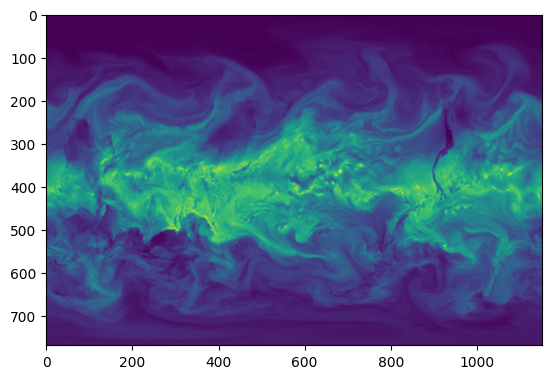

In [41]:
plt.imshow(x_val[0,0,:,:])

In [8]:
# --- 1. synthetic data with *multiple* blobs and noisy annotators -------------
B, H, W = 4, 128, 128
yy, xx  = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')

# ground-truth centres & radii
centers = [(32, 32), (96, 40), (64, 96)]
radii   = [14, 18, 10]

# -------- correct: build TRUE mask as bool -----------------------------------
true_mask = torch.zeros(H, W, dtype=torch.bool)
for (cy, cx), r in zip(centers, radii):
    true_mask |= (yy - cy)**2 + (xx - cx)**2 < r**2        # bool OR
true_mask = true_mask.float()                              # convert once

# -------- helper returns bool, then casts ------------------------------------
def jitter_blobs(mask_bool, shift_px=2, radius_jitter=2, drop_prob=0.15):
    noisy = torch.zeros_like(mask_bool, dtype=torch.bool)
    for (cy, cx), r in zip(centers, radii):
        dy, dx = torch.randint(-shift_px, shift_px + 1, (2,))
        r2 = max(4, r + torch.randint(-radius_jitter, radius_jitter + 1, ()))
        if torch.rand(1).item() < drop_prob:
            continue
        blob = (yy - (cy + dy))**2 + (xx - (cx + dx))**2 < r2**2
        noisy |= blob                                         # safe: bool
    # salt-and-pepper
    # salt-and-pepper noise — now dtype=float so uniform() is valid
        noisy ^= (torch.rand_like(noisy, dtype=torch.float32) < 0.02)

    return noisy.float()                                      # return float

ann1 = jitter_blobs(true_mask.bool(), shift_px=1, radius_jitter=1, drop_prob=0.05)
ann2 = jitter_blobs(true_mask.bool(), shift_px=3, radius_jitter=3, drop_prob=0.10)
ann3 = jitter_blobs(true_mask.bool(), shift_px=4, radius_jitter=4, drop_prob=0.25)

# -------- stack & consensus ---------------------------------------------------
y_stack = torch.stack([ann1, ann2, ann3])          # 3, H, W   (float 0/1)
y_cons  = y_stack.mean(0, keepdim=True)   

step 000  loss 0.7726
step 060  loss 0.1653
step 120  loss 0.1268
step 180  loss 0.1214
step 240  loss 0.1191


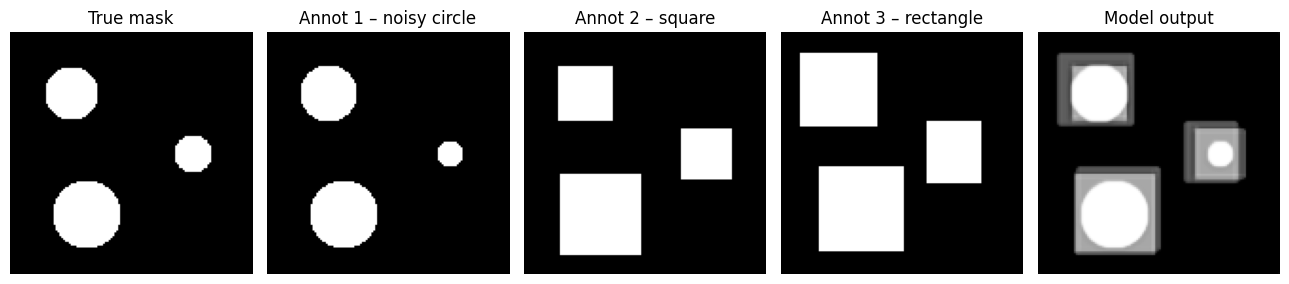

In [18]:
# ========================================================
# 0. imports & helpers
# ========================================================
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --------------------------------------------------------
# 1. synthetic data with blobs + 3 very different annotators
# --------------------------------------------------------
B, H, W = 4, 128, 128
yy, xx  = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')

# ground-truth = perfect circles
centers = [(32, 32), (96, 40), (64, 96)]
radii   = [14, 18, 10]

true_mask = torch.zeros(H, W, dtype=torch.bool)
for (cy, cx), r in zip(centers, radii):
    true_mask |= (yy - cy)**2 + (xx - cx)**2 < r**2
true_mask = true_mask.float()

# ----- annotator 1 – noisy circles -------------------------------------------
def anno1_circle_noise():
    m = torch.zeros_like(true_mask, dtype=torch.bool)
    for (cy, cx), r in zip(centers, radii):
        r2 = max(4, r + torch.randint(-3, 4, ()))        # ±3 px radius jitter
        m |= (yy - cy)**2 + (xx - cx)**2 < r2**2
    return m.float()

# ----- annotator 2 – squares --------------------------------------------------
def anno2_squares():
    m = torch.zeros_like(true_mask, dtype=torch.bool)
    for (cy, cx), r in zip(centers, radii):
        d = r + torch.randint(0, 4, ())                  # square half-size
        m[cy-d: cy+d+1, cx-d: cx+d+1] = True
    return m.float()

# ----- annotator 3 – shifted rectangles --------------------------------------
def anno3_rectangles():
    m = torch.zeros_like(true_mask, dtype=torch.bool)
    for (cy, cx), r in zip(centers, radii):
        h = r + torch.randint(3, 8, ())                  # random height
        w = r + torch.randint(3, 8, ())                  # random width
        dy, dx = torch.randint(-6, 7, (2,))              # centre shift
        ys, xs = cy+dy-h, cx+dx-w
        ye, xe = cy+dy+h, cx+dx+w
        ys, xs = max(0, ys), max(0, xs)
        ye, xe = min(H-1, ye), min(W-1, xe)
        m[ys:ye+1, xs:xe+1] = True
    return m.float()

ann1 = anno1_circle_noise()
ann2 = anno2_squares()
ann3 = anno3_rectangles()

# ---------- batch-stack -------------------------------------------------------
y_stack = torch.stack([ann1, ann2, ann3]).repeat(B, 1, 1, 1)  # B,3,H,W
y_cons  = y_stack.mean(1, keepdim=True)                       # B,1,H,W

# --------------------------------------------------------
# 2. simple feature-extract-and-fuse network
# --------------------------------------------------------
class SubEnc(nn.Module):
    def __init__(self, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, hidden, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class FuseNet(nn.Module):
    def __init__(self, n_ann=3, hidden=8):
        super().__init__()
        self.br = nn.ModuleList([SubEnc(hidden) for _ in range(n_ann)])
        self.fuse = nn.Sequential(
            nn.Conv2d(hidden*n_ann, hidden*2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden*2, 1, 1)     # 1-channel logit map
        )
    def forward(self, y):
        feats = [b(y[:, i:i+1]) for i, b in enumerate(self.br)]
        return self.fuse(torch.cat(feats, dim=1))

net  = FuseNet().to(device)
opt  = torch.optim.Adam(net.parameters(), 1e-3)
crit = nn.BCEWithLogitsLoss()

# --------------------------------------------------------
# 3. quick training loop (300 steps)
# --------------------------------------------------------
for step in range(300):
    opt.zero_grad()
    logit = net(y_stack.to(device))
    loss  = crit(logit, y_cons.to(device))
    loss.backward(); opt.step()
    if step % 60 == 0:
        print(f"step {step:03d}  loss {loss.item():.4f}")

# --------------------------------------------------------
# 4. visualize one batch sample
# --------------------------------------------------------
with torch.no_grad():
    idx   = 0
    pred  = torch.sigmoid(net(y_stack.to(device))[idx,0]).cpu() 
    imgs  = [true_mask, ann1, ann2, ann3, pred]
    titles= ['True mask','Annot 1 – noisy circle','Annot 2 – square',
             'Annot 3 – rectangle','Model output']
    plt.figure(figsize=(13,3))
    for i,(im,tt) in enumerate(zip(imgs,titles)):
        plt.subplot(1,5,i+1); plt.imshow(im,cmap='gray'); plt.title(tt); plt.axis('off')
    plt.tight_layout(); plt.show()


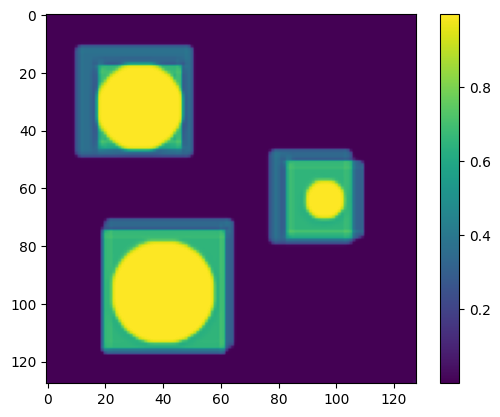

In [21]:
plt.imshow(pred)
plt.colorbar()

In [22]:
import glob, re, xarray as xr, torch
from pathlib import Path
from torch.utils.data import Dataset

class ARMultiAnnDataset(Dataset):
    def __init__(self, folder, var_names, transform=None):
        self.folder     = Path(folder)
        self.var_names  = var_names          # list like ["IVT", "IWV", ...]
        self.transform  = transform

        # 1) group nc files by date (regex grabs YYYY-MM-DD)
        patt = re.compile(r"data-(\d{4}-\d{2}-\d{2})-.*?_(\d+)\.nc$")
        by_date = {}
        for f in glob.glob(str(self.folder / "*.nc")):
            m = patt.search(Path(f).name)
            if not m: continue
            date_key  = m.group(1)
            ann_idx   = int(m.group(2))
            by_date.setdefault(date_key, {})[ann_idx] = f
        self.samples = list(by_date.items())   # [(date, {ann: path, ...}), ...]

    def __len__(self): return len(self.samples)

    def _load_nc(self, path):
        ds = xr.open_dataset(path, engine="netcdf4")
        x  = torch.stack([torch.tensor(ds[v].values) for v in self.var_names]) # C,H,W
        y  = torch.tensor(ds["LABELS"].values).unsqueeze(0)                    # 1,H,W
        ds.close()
        return x.float(), y.float()

    def __getitem__(self, idx):
        date, ann_dict = self.samples[idx]

        xs, ys = [], []
        for p in ann_dict.values():                       # iterate annotators
            x, y = self._load_nc(p)
            xs.append(x)          # they’re identical across annotators → keep one
            ys.append(y)
        x  = xs[0]                                    # choose variables once
        y_stack = torch.cat(ys, dim=0)                # N,H,W
        y_cons  = y_stack.mean(0, keepdim=True)       # 1,H,W

        if self.transform:
            x, y_stack, y_cons = self.transform(x, y_stack, y_cons)
        return x, y_stack, y_cons


In [27]:
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import random # optional mixed precision

device  = "cuda" if torch.cuda.is_available() else "cpu"
vars_   = ["TMQ"]           # 16 variable names in .nc
ds      = ARMultiAnnDataset("/home/sbk29/data/AR/train", vars_)
loader  = DataLoader(ds, batch_size=2, shuffle=True, num_workers=8)

In [46]:
for idx in random.sample(range(len(ds_var)), 10):
    x, y_stack, y_cons = ds[idx]
    print(f"Sample #{idx}")
    print("  x        :", x.shape, x.dtype)           # e.g. [16,256,256] float32
    print("  y_stack  :", y_stack.shape, y_stack.dtype,
          " (annotators =", y_stack.shape[0], ")")
    print("  y_cons   :", y_cons.shape, "min/max =", 
          float(y_cons.min()), float(y_cons.max()))
    print("-" * 60)

Sample #91
  x        : torch.Size([1, 1, 768, 1152]) torch.float32
  y_stack  : torch.Size([2, 768, 1152]) torch.float32  (annotators = 2 )
  y_cons   : torch.Size([1, 768, 1152]) min/max = 0.0 2.0
------------------------------------------------------------
Sample #184
  x        : torch.Size([1, 1, 768, 1152]) torch.float32
  y_stack  : torch.Size([1, 768, 1152]) torch.float32  (annotators = 1 )
  y_cons   : torch.Size([1, 768, 1152]) min/max = 0.0 2.0
------------------------------------------------------------
Sample #55
  x        : torch.Size([1, 1, 768, 1152]) torch.float32
  y_stack  : torch.Size([3, 768, 1152]) torch.float32  (annotators = 3 )
  y_cons   : torch.Size([1, 768, 1152]) min/max = 0.0 2.0
------------------------------------------------------------
Sample #69
  x        : torch.Size([1, 1, 768, 1152]) torch.float32
  y_stack  : torch.Size([1, 768, 1152]) torch.float32  (annotators = 1 )
  y_cons   : torch.Size([1, 768, 1152]) min/max = 0.0 2.0
--------------------

In [47]:
print(f"🚀  Found {len(ds_var):,} unique dates with at least one annotator file\n")

🚀  Found 188 unique dates with at least one annotator file



In [48]:
assert torch.allclose(x, ds[idx][0]), "Variables differ across annotator files!"

In [49]:
# ------------------------------------------------------------
# 3. run a quick DataLoader pass
# ------------------------------------------------------------
loader = DataLoader(ds_var, batch_size=2, shuffle=True, num_workers=8, pin_memory=True)

x_b, y_stack_b, y_cons_b = next(iter(loader))
print("Batch shapes:")
print("  x_batch       :", x_b.shape)        # [B, C_in, H, W]
print("  y_stack_batch :", y_stack_b.shape)  # [B, N,     H, W]
print("  y_cons_batch  :", y_cons_b.shape)   # [B, 1,     H, W]

# move one batch through your model if you wish
net = ARFuseNet(c_vars=len(vars_)).to(device).eval()
with torch.no_grad():
    logits = net(x_b.to(device), y_stack_b.to(device))
print("  logits        :", logits.shape, logits.dtype)

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py", line 212, in collate
    collate(samples, collate_fn_map=collate_fn_map)
  File "/home/s

In [38]:
# ---------- tiny encoder for stacked masks (annotator branch) ----------
class AnnEncoder(nn.Module):
    def __init__(self, n_ann, c_out=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(n_ann, 16, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(16, c_out, 3, 1, 1), nn.ReLU(inplace=True),
        )
    def forward(self, y): return self.net(y)      # (B, c_out, H, W)

# ---------- fusion head -------------------------------------------------------
class ARFuseNet(nn.Module):
    def __init__(self, c_vars, base=32, c_ann=16):
        super().__init__()
        self.var_enc = VarUNet(c_vars, base)      # returns  base channels
        self.ann_enc = AnnEncoder(n_ann=3, c_out=c_ann)
        self.fuse    = nn.Sequential(
            nn.Conv2d(base + c_ann, base, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(base, 1, 1)                  # logits
        )
    def forward(self, x_vars, y_stack):
        f_vars = self.var_enc(x_vars)
        f_ann  = self.ann_enc(y_stack)
        f      = torch.cat([f_vars, f_ann], dim=1)
        return self.fuse(f)                       # B,1,H,W  (raw logits)

In [2]:
# ar_multi_ann_dataset.py
# -----------------------------------------------------------
import re, glob
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import torch
import xarray as xr
from torch.utils.data import Dataset

# ------------------------------------------------------------------
# 1. regex that extracts (date, annotator_id) from your filenames
# ------------------------------------------------------------------
#  └─  data-2000-12-20-01-1_0.nc
#                       ^^^^^^ last '_' then digits then '.nc'
FNAME_RE = re.compile(
    r"data-"                # literal prefix
    r"(\d{4}-\d{2}-\d{2})"  # group 1: YYYY-MM-DD
    r"-.*?_"                # non-greedy up to final underscore
    r"(\d+)"                # group 2: annotator ID
    r"\.nc$"                # literal '.nc' at end
)

# ------------------------------------------------------------------
# 2. the dataset
# ------------------------------------------------------------------
class ARMultiAnnDataset(Dataset):
    """
    Loads Atmospheric-River NetCDF tiles that have multiple annotators.

    Each __getitem__ returns
      x_vars   : torch.FloatTensor [C_in, H, W]          – data variables
      y_list   : list[FloatTensor 1×H×W]  length = N_i   – 1 mask per annotator
      y_cons   : FloatTensor [1, H, W]                   – mean-vote consensus

    If you prefer *fixed* N for batching, set `max_ann > 0` and the class will
    pad / truncate y_list to that length and return a *stack*
      y_stack  : FloatTensor [max_ann, H, W]
    """

    def __init__(
        self,
        root: str | Path,
        var_names: List[str],
        max_ann: int | None = None,         # None → variable-length
        transform=None                      # optional augmentation callable
    ):
        super().__init__()
        self.root       = Path(root)
        self.var_names  = var_names
        self.max_ann    = max_ann
        self.transform  = transform

        # ----------------------------------------------------------
        # Group every .nc in root by date
        # samples -> list[ (date_str, {annot_id : path, ...}) ]
        # ----------------------------------------------------------
        by_date: Dict[str, Dict[int, Path]] = {}
        for f in glob.glob(str(self.root / "*.nc")):
            m = FNAME_RE.search(Path(f).name)
            if not m:
                raise ValueError(f"Filename {f} does not match expected pattern")
            date_key  = m.group(1)          # '2000-12-20'
            annot_id  = int(m.group(2))     # 0,1,2,...
            by_date.setdefault(date_key, {})[annot_id] = Path(f)

        self.samples: List[Tuple[str, Dict[int, Path]]] = sorted(by_date.items())
        if not self.samples:
            raise RuntimeError(f"No NetCDF files found in {root}")

        # Optional: remember real max annotators
        self.real_max_ann = max(len(d) for _, d in self.samples)
        if self.max_ann and self.max_ann < self.real_max_ann:
            print(f"⚠️  max_ann={self.max_ann} but dataset contains up to "
                  f"{self.real_max_ann} annotators – will truncate.")

    # ---------------------------- helpers --------------------------
    def _load_nc(self, path: Path) -> Tuple[torch.Tensor, torch.Tensor]:
        ds = xr.open_dataset(path, engine="netcdf4")

        # squeeze() drops ANY singleton dimension, e.g. the leading "time=1"
        vars_arr = [
            torch.as_tensor(ds[v].values).squeeze()     # (H, W) after squeeze
            for v in self.var_names
        ]
        x = torch.stack(vars_arr).float()               # [C, H, W]
        raw = torch.as_tensor(ds["LABELS"].values).squeeze()  
        y   = (raw == 2).float().unsqueeze(0)    

        # y = torch.as_tensor(ds["LABELS"].values).squeeze().unsqueeze(0).float()
        ds.close()
        return x, y
    # ----------------------------------------------------------------

    # --------------------- torch API --------------------------------
    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx):
        date_key, ann_map = self.samples[idx]

        x_vars, y_list = None, []
        for p in ann_map.values():                     # iterate annotators
            x, y = self._load_nc(p)
            if x_vars is None:
                x_vars = x                # identical across annotators
            y_list.append(y)

        # ---------------- optional fixed size ----------------------
        if self.max_ann is not None:
            if len(y_list) > self.max_ann:
                y_list = y_list[: self.max_ann]             # cut
            while len(y_list) < self.max_ann:
                pad = torch.zeros_like(y_list[0])
                y_list.append(pad)
            # stack immediately
            y_stack = torch.cat(y_list, dim=0)              # [max_ann,H,W]
        # -----------------------------------------------------------

        # consensus = mean vote  (always 1×H×W)
        y_cons = torch.stack(y_list, dim=0).mean(0)

        # ------- optional transform (x, list/stack, y_cons) -------
        if self.transform:
            if self.max_ann is None:
                x_vars, y_list, y_cons = self.transform(x_vars, y_list, y_cons)
            else:
                x_vars, y_stack, y_cons = self.transform(x_vars, y_stack, y_cons)

        # ------- return according to max_ann flag ------------------
        if self.max_ann is None:
            return x_vars, y_list, y_cons       # variable-length list
        else:
            return x_vars, y_stack, y_cons      # fixed-size tensor


In [3]:
from torch.utils.data import DataLoader

var_names = ["IVT", "IWV", "U850", "V850", ...]  # 16 variables in each .nc

# Case 1 - variable number of annotators (needs a custom collate, see below)
ds_var  = ARMultiAnnDataset("/home/sbk29/data/AR/train", var_names, max_ann=None)

# Case 2 - force a fixed maximum of 5 annotators (zero-padded)
# ds_fix  = ARMultiAnnDataset("/home/sbk29/data/AR/train", var_names, max_ann=5)

# ---------------------------------------------------------
# A. variable length → custom collate that keeps lists
# ---------------------------------------------------------
def collate_var(batch):
    xs, y_lists, y_cons = zip(*batch)   # tuples
    xs     = torch.stack(xs)           # [B,C,H,W]
    y_cons = torch.stack(y_cons)       # [B,1,H,W]
    return xs, y_lists, y_cons

loader_var = DataLoader(ds_var, batch_size=4, collate_fn=collate_var)

# ---------------------------------------------------------
# B. fixed length (padding done in Dataset) → default collate
# ---------------------------------------------------------
loader_fix = DataLoader(ds_fix, batch_size=4)   # y_stack is tensor already


NameError: name 'ds_fix' is not defined

In [2]:
class AnnEncoder(nn.Module):
    """
    Encode each annotator mask with the same CNN, then pool.
    pooling = 'mean' | 'max' | 'attention'
    """
    def __init__(self, c_out=16, pooling="mean"):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 8, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(8, c_out, 3, 1, 1), nn.ReLU(True)
        )
        self.pooling = pooling
        if pooling == "attention":
            self.att_query = nn.Parameter(torch.randn(c_out))

    def forward(self, y_list):            # y_list: list[Tensor 1×H×W]
        if len(y_list) == 0:              # safety: no annotator
            raise ValueError("empty annotator list")

        feats = [self.enc(y.unsqueeze(0)) for y in y_list]  # each → 1,c_out,H,W
        feats = torch.stack(feats, dim=0)   # N,c_out,H,W

        if self.pooling == "mean":
            return feats.mean(0)            # 1,c_out,H,W
        elif self.pooling == "max":
            return feats.max(0).values
        else:                               # simple attention pooling
            w = torch.einsum('nchw,c->n', feats, self.att_query).softmax(0)
            fused = (feats * w[:, None, None, None]).sum(0)
            return fused                    # 1,c_out,H,W


NameError: name 'nn' is not defined

In [45]:
###############################################################
# 2.  instantiate the model parts
###############################################################
device      = "cuda" if torch.cuda.is_available() else "cpu"

var_unet    = VarUNet(c_in=len(var_names), base=32).to(device)
ann_encoder = AnnEncoder(c_out=16, pooling="mean").to(device)

# simple fusion head: concat → 1×1 conv → logits
head = nn.Conv2d(32 + 16, 1, kernel_size=1).to(device)

opt  = torch.optim.AdamW(
    list(var_unet.parameters()) +
    list(ann_encoder.parameters()) +
    list(head.parameters()),
    lr=1e-4
)
loss_fn = nn.BCEWithLogitsLoss()

###############################################################
# 3.  training loop
###############################################################
for epoch in range(3):
    var_unet.train(); ann_encoder.train(); head.train()
    for x_vars, y_lists, y_cons in loader:              # y_lists is list-of-lists
        x_vars, y_cons = x_vars.to(device), y_cons.to(device)

        # --- encode each sample’s annotator set separately  ----
        ann_feats = []
        for y_list in y_lists:                          # length B (python loop)
            # move every mask tensor in this list to GPU
            y_gpu = [m.to(device) for m in y_list]
            ann_feats.append(ann_encoder(y_gpu))        # -> 1,c_ann,H,W

        ann_feats = torch.cat(ann_feats, dim=0)         # [B,c_ann,H,W]
        var_feats = var_unet(x_vars)                    # [B,base,H,W]

        logits = head(torch.cat([var_feats, ann_feats], dim=1))  # [B,1,H,W]
        loss   = loss_fn(logits, y_cons)

        opt.zero_grad()
        loss.backward()
        opt.step()

    print(f"epoch {epoch:02d}  loss {loss.item():.4f}")

NameError: name 'VarUNet' is not defined

In [39]:
# ===========================================================
# Sanity-check for ARMultiAnnDataset
# ===========================================================
import random, torch
from torch.utils.data import DataLoader

# -------- update these two lines ---------------------------------
root      = "/home/sbk29/data/AR/train"                          # folder with .nc files
var_names = ["TMQ"]  # your 16 variables
# -----------------------------------------------------------------

# 1️⃣  choose dataset version  (variable-length vs fixed-length)
ds = ARMultiAnnDataset(root, var_names, max_ann=None)   # or max_ann=5

print(f"\n🗂  Found {len(ds):,} unique dates")
print(f"   Real max annotators per date : {ds.real_max_ann}\n")

# 2️⃣  look at three random items
for idx in random.sample(range(len(ds)), 3):
    sample = ds[idx]
    x_vars     = sample[0]                     # [C_in,H,W]
    y_cons     = sample[-1]                    # [1,H,W]

    if ds.max_ann is None:
        y_list = sample[1]
        n_ann  = len(y_list)
        print(f"Sample #{idx:3d}  | annotators = {n_ann}")
        print("  x_vars :", tuple(x_vars.shape), x_vars.dtype)
        print("  y[0]   :", tuple(y_list[0].shape), y_list[0].dtype)
    else:
        y_stack = sample[1]
        n_ann   = y_stack.shape[0]
        print(f"Sample #{idx:3d}  | annotators = {n_ann} (stacked)")
        print("  x_vars :", tuple(x_vars.shape))
        print("  y_stack:", tuple(y_stack.shape))

    print("  y_cons :", tuple(y_cons.shape),
          "min/max =", float(y_cons.min()), float(y_cons.max()))
    print("-"*60)

# 3️⃣  build a DataLoader and fetch one batch
def collate_var(batch):                       # only for variable-length
    xs, y_lists, y_cons = zip(*batch)
    return torch.stack(xs), list(y_lists), torch.stack(y_cons)

loader = DataLoader(ds,
                    batch_size=8,
                    shuffle=True,
                    num_workers=0,
                    pin_memory=True,
                    collate_fn=collate_var if ds.max_ann is None else None)

x_b, ys_b, yc_b = next(iter(loader))

print("\n✅  Batch check")
print("  x_batch :", tuple(x_b.shape))        # [B,C,H,W]

if ds.max_ann is None:
    print("  ys_b is list with lengths:", [len(l) for l in ys_b])
else:
    print("  y_stack:", tuple(ys_b.shape))    # [B,max_ann,H,W]

print("  y_cons :", tuple(yc_b.shape))        # [B,1,H,W]


TypeError: ARMultiAnnDataset.__init__() got an unexpected keyword argument 'max_ann'

In [5]:
from train_model import SegNet, ARMultiAnnDataset, collate_var, FNAME_RE, POST_RE

In [3]:
import torch
from torch.utils.data import DataLoader

def predict_masks_gpu(
    ckpt_path: str,
    label_dir:     str,
    data_dir:    str,
    var_names:  list[str],
    batch_size: int    = 4,
    use_masks:  bool   = True,
    device:     str    = "cuda"
) -> tuple[torch.Tensor, torch.Tensor]:

    # 1) load checkpoint (weights_only=True silences the pickle warning)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)

    # extract the state_dict whichever form it’s in
    if isinstance(ckpt, dict) and "model" in ckpt:
        sd = ckpt["model"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        sd = ckpt["state_dict"]
    else:
        sd = ckpt  # assume ckpt *is* the state dict

    # 2) build & load your SegNet
    net = SegNet().to(device).eval()
    net.load_state_dict(sd)

    # 3) dataset + loader
    ds = ARMultiAnnDataset(
        root        = data_dir,
        var_names   = var_names,
        gt_npy_root = label_dir
    )
    dl = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        collate_fn=collate_var, pin_memory=(device=="cuda")
    )

    preds, gts = [], []
    autocast    = torch.amp.autocast

    # 4) inference
    with torch.no_grad(), autocast(device_type=device, dtype=torch.float16):
        for x_vars, y_lists, y_cons in dl:
            x_vars = x_vars.to(device)

            if use_masks:
                y_lists = [
                    [m.to(device, dtype=x_vars.dtype) for m in lst]
                    for lst in y_lists
                ]
                logits = net(x_vars)
            else:
                logits = net(x_vars)

            probs = torch.sigmoid(logits)
            preds.append(probs.cpu())
            gts  .append(y_cons)   # already on CPU

    PRED = torch.cat(preds, dim=0)  # [N,1,H,W], fp16
    GT   = torch.cat(gts,   dim=0)  # [N,1,H,W], fp32

    return PRED, GT


In [4]:


pred, gt = predict_masks_gpu(
    ckpt_path = "/home/sbk29/data/github_AR/AR_detection/u-net/runs/arseg/unet_BCE_Dice.pt",
    data_dir  = "/home/sbk29/data/AR/test_val",
    label_dir = None,
    var_names = ["TMQ"],
    batch_size= 4,
    use_masks = "True",          # no human masks available
    device    = "cuda"          # keep everything on GPU
)

  # torch.Size([N,1,768,1152])  cuda:0


In [5]:
import numpy as np

In [6]:
pred = np.array(pred)
gt = np.array(gt)


In [7]:
pred.shape

(31, 1, 768, 1152)

In [9]:
gt.shape

(31, 1, 768, 1152)

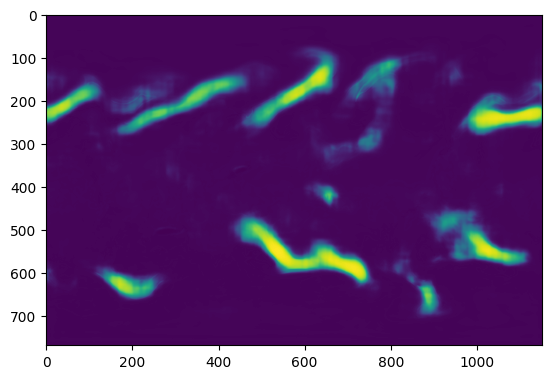

In [8]:
plt.imshow(pred[20,0,:,:])

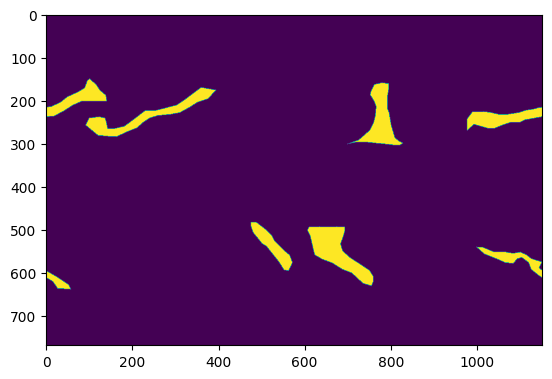

In [12]:
plt.imshow(true_mask[20,:,:])

In [10]:
true_mask = np.array(gt[:,0,:,:]>0.5)  # Size : (B, 768, 1152)
score_whole = np.array(pred) # Size : (B, 1, 768, 1152)

In [13]:
N,H,W = true_mask.shape

In [14]:
z_test = score_whole.reshape(-1)          # (N·H·W,)
y_test = true_mask.reshape(-1)   

In [15]:
import numpy as np
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az

In [18]:
del pred, gt

In [18]:

# 1) Send your data to the GPU
#    z: logits, shape (Npix,)
#    y: labels 0/1, same shape
z_flat = jnp.asarray(z_test.astype("float32"))
y_flat = jnp.asarray(y_test.astype("int32"))

# 2) Define the Platt‐scaling model
def platt_model(z, y=None):
    A = numpyro.sample("A", dist.Normal(0.0, 10.0))
    B = numpyro.sample("B", dist.Normal(0.0, 10.0))
    logits = A * z + B
    numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        
# 3) Set up and run NUTS on the GPU
kernel = NUTS(platt_model, target_accept_prob=0.9)
mcmc   = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=1)
rng_key = jax.random.PRNGKey(0)

mcmc.run(rng_key, z=z_flat, y=y_flat)
mcmc.print_summary()   # shows mean, sd, R-hat, ESS for A and B

# 4) Extract posterior samples of A, B
posterior = mcmc.get_samples()
A_draws   = posterior["A"]   # shape (1000,)
B_draws   = posterior["B"]

sample: 100%|██████████| 2000/2000 [00:33<00:00, 59.82it/s, 15 steps of size 2.15e-01. acc. prob=0.92] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A      6.32      0.00      6.32      6.31      6.33    234.69      1.00
         B     -4.35      0.00     -4.35     -4.35     -4.34    364.46      1.00

Number of divergences: 0


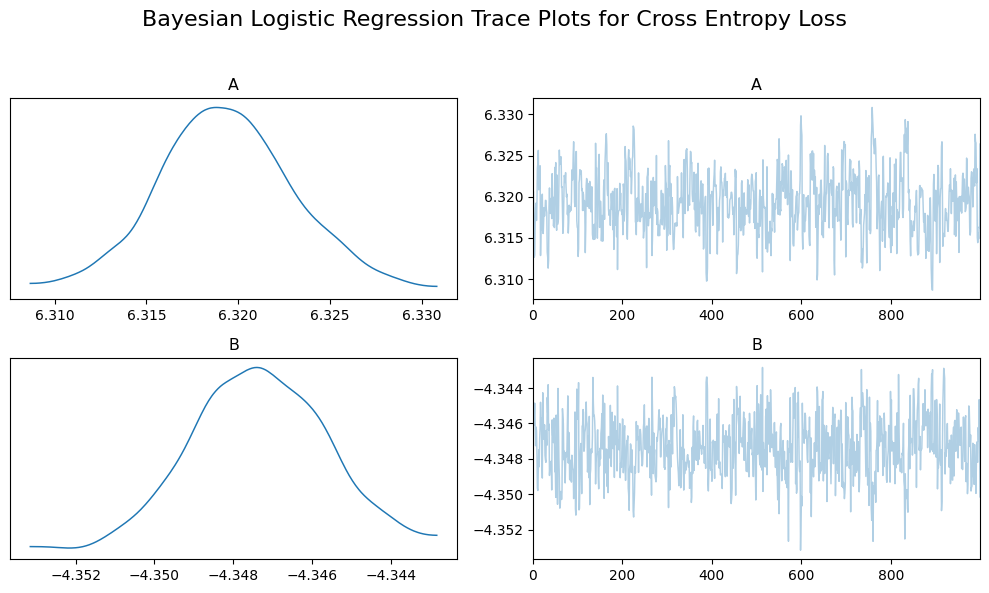

In [19]:
# 1) Extract posterior draws from your MCMC object
posterior = mcmc.get_samples()    # these are JAX DeviceArrays on GPU

# 2) Move A and B to NumPy on the host
A_np = np.asarray(posterior["A"])  # shape (n_samples,)
B_np = np.asarray(posterior["B"])

# 3) Create an ArviZ InferenceData from a Python dict
idata = az.from_dict(posterior={"A": A_np, "B": B_np})

# 4) Plot the trace
axes = az.plot_trace(idata, var_names=["A", "B"], figsize=(10, 6))

# 5) Add a super‐title and tighten layout
plt.suptitle("Bayesian Logistic Regression Trace Plots for Cross Entropy Loss", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [20]:
A_hat = np.mean(A_np)
B_hat = np.mean(B_np)

In [21]:
p_hat = 1/(1 + np.exp(-(A_hat * z_test + B_hat)))

In [22]:
p_hat = p_hat.reshape(N,H,W)

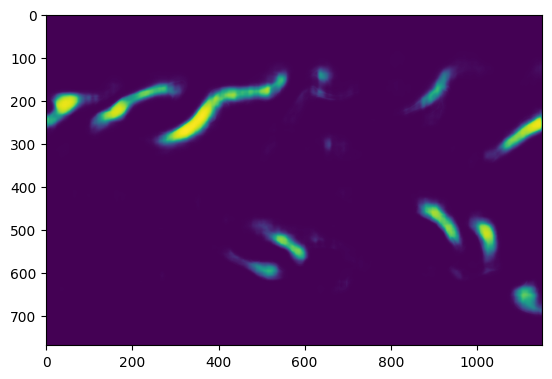

In [46]:
plt.imshow(p_hat[10,:,:])

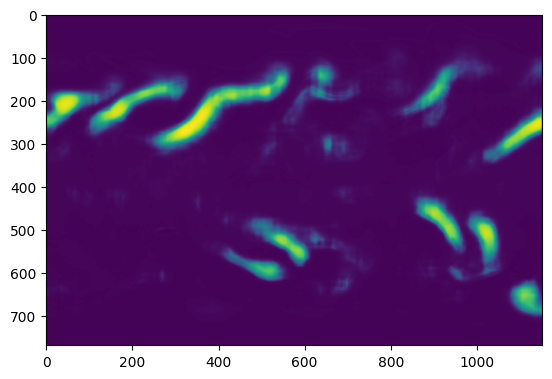

In [45]:
plt.imshow(pred[10,0,:,:])

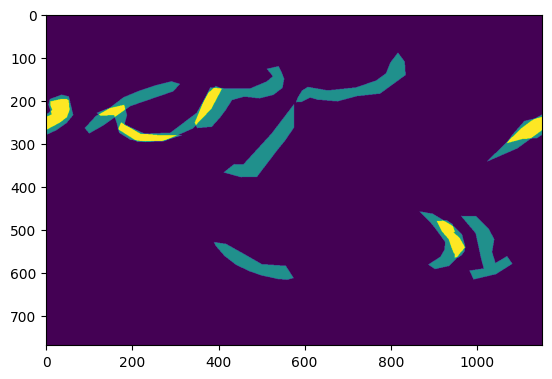

In [44]:
plt.imshow(gt[10,0,:,:])

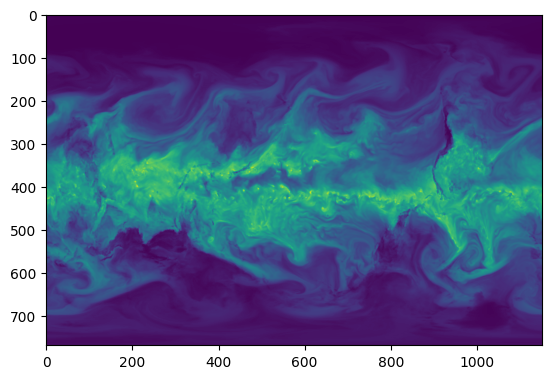

In [47]:
plt.imshow(x_val[10,0,:,:])

In [20]:
import torch
from torch.utils.data import DataLoader

def predict_and_collect(ckpt_path : str,
                        data_dir  : str,
                        label_dir : str,
                        var_names : list[str],
                        batch_size: int   = 4,
                        use_masks : bool  = True,   # pass annotators to net
                        device    : str   = "cuda"  # "cuda" | "cpu"
                       ) -> tuple[torch.Tensor, torch.Tensor]:

    # 1 ─ load network
    ckpt = torch.load(ckpt_path, map_location=device)
    net  = SegNet(len(var_names)).to(device).eval()
    net.load_state_dict(ckpt["model"])

    # 2 ─ dataset & loader
    ds = ARMultiAnnDataset(data_dir, var_names, label_dir)
    dl = DataLoader(ds, batch_size=batch_size,
                    shuffle=False, collate_fn=collate_var,
                    pin_memory=(device == "cuda"))

    preds, gts = [] , []
    ac = torch.amp.autocast                            # shorthand
    with torch.no_grad(), ac(device_type=device, dtype=torch.float16):
        for x_vars, y_lists, y_cons in dl:
            x_vars, y_cons = x_vars.to(device), y_cons.to(device)

            if not use_masks:                         # inference w/o labels
                y_lists = [[] for _ in y_lists]       # empty list → zero-features
            else:                                     # move masks to GPU & cast
                y_lists = [[m.to(device, dtype=x_vars.dtype, non_blocking=True)
                           for m in lst] for lst in y_lists]

            logits = net(x_vars)             # [B,1,H,W] fp16
            preds.append(torch.sigmoid(logits))       # keep fp16
            gts  .append(y_cons.float())              # store fp32 for metrics

    PRED = torch.cat(preds, dim=0)                    # [N,1,H,W] fp16
    GT   = torch.cat(gts,   dim=0)                    # [N,1,H,W] fp32
    return PRED, GT


In [21]:
pred, gt = predict_and_collect(
    ckpt_path  = "/home/sbk29/data/github_AR/AR_detection/u-net/runs/arseg/unet_BCE_Dice.pt",
    data_dir   = "/home/sbk29/data/AR/validation",
    label_dir = "/home/sbk29/data/github_AR/AR_detection/u-net/ds_results",
    var_names  = ["TMQ"],
    batch_size = 4,
    use_masks  = True,    # False if the test split has *no* annotator files
    device     = "cuda"
)

print("pred", pred.shape, pred.dtype, pred.device)
print("gt  ", gt.shape,   gt.dtype,   gt.device)


/tmp/ipykernel_2164887/2736267442.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


TypeError: SegNet.__init__() takes 1 positional argument but 2 were given

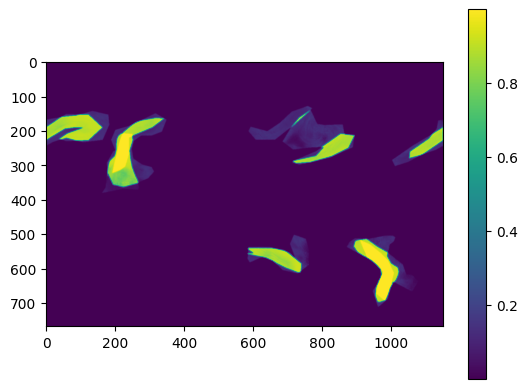

In [78]:
plt.imshow(pred[2,0,:,:].cpu())
plt.colorbar()

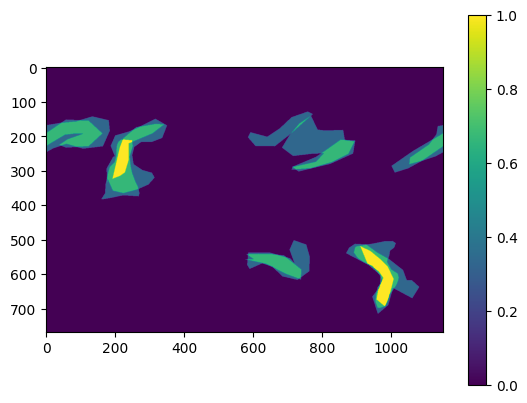

In [76]:
plt.imshow(gt[2,0,:,:].cpu())
plt.colorbar()

In [62]:
gt.shape

torch.Size([16, 1, 768, 1152])

In [74]:
pred[1,0,:,:]

tensor([[1.3535e-02, 1.2302e-03, 7.1526e-04,  ..., 5.9748e-04, 9.7370e-04,
         1.0567e-02],
        [1.8892e-03, 3.9756e-05, 1.7941e-05,  ..., 1.4603e-05, 3.0458e-05,
         1.2207e-03],
        [1.9646e-03, 4.7207e-05, 2.3186e-05,  ..., 1.7226e-05, 4.1962e-05,
         1.0691e-03],
        ...,
        [2.0428e-03, 4.3988e-05, 2.2829e-05,  ..., 4.3631e-05, 1.0073e-04,
         2.8553e-03],
        [1.8101e-03, 4.4346e-05, 2.2113e-05,  ..., 3.0458e-05, 6.9737e-05,
         1.7338e-03],
        [1.4671e-02, 1.0204e-03, 6.9046e-04,  ..., 8.3590e-04, 1.6041e-03,
         1.5839e-02]], device='cuda:0', dtype=torch.float16)

In [30]:
# ─── sanity_check_dataset.py ──────────────────────────────────────────
import random, torch
from torch.utils.data import DataLoader

# 0️⃣  EDIT THESE TWO LINES
root_dir   = "/home/sbk29/data/AR/validation"          # folder with .nc files
var_names  = ["TMQ"]                              # or ["IVT","IWV",...]

# 1️⃣  build dataset + loader
ds = ARMultiAnnDataset(root_dir, var_names)       # return_raw=False by default
print(f"\n🗂  Found {len(ds):,} unique dates")
print(f"    Max annotators/date : {ds.real_max_ann}\n")

# 2️⃣  inspect three random items
for idx in random.sample(range(len(ds)), 3):
    x_vars, y_list, y_cons = ds[idx]
    print(f"Sample #{idx:3d}")
    print("  x_vars :", tuple(x_vars.shape), x_vars.dtype)   # [C,H,W]
    print("  # annot :", len(y_list))
    print("  y[0]   :", tuple(y_list[0].shape), y_list[0].dtype)
    print("  y_cons :", tuple(y_cons.shape),
          " min/max =", float(y_cons.min()), float(y_cons.max()))
    print("-"*60)

# 3️⃣  batch check
def collate_var(batch):
    xs, y_lists, y_cons = zip(*batch)
    return torch.stack(xs), list(y_lists), torch.stack(y_cons)

loader = DataLoader(ds, batch_size=2, collate_fn=collate_var, num_workers=0)

x_b, y_b, yc_b = next(iter(loader))
print("\n✅  Batch shapes")
print("  x_batch       :", tuple(x_b.shape))        # [B,C,H,W]
print("  y_lists lens  :", [len(l) for l in y_b])   # variable annotators
print("  y_cons_batch  :", tuple(yc_b.shape))       # [B,1,H,W]



🗂  Found 16 unique dates
    Max annotators/date : 3

Sample # 13
  x_vars : (1, 768, 1152) torch.float32
  # annot : 2
  y[0]   : (1, 768, 1152) torch.float32
  y_cons : (1, 768, 1152)  min/max = 0.0 1.0
------------------------------------------------------------
Sample # 15
  x_vars : (1, 768, 1152) torch.float32
  # annot : 1
  y[0]   : (1, 768, 1152) torch.float32
  y_cons : (1, 768, 1152)  min/max = 0.0 1.0
------------------------------------------------------------
Sample #  8
  x_vars : (1, 768, 1152) torch.float32
  # annot : 3
  y[0]   : (1, 768, 1152) torch.float32
  y_cons : (1, 768, 1152)  min/max = 0.0 1.0
------------------------------------------------------------

✅  Batch shapes
  x_batch       : (2, 1, 768, 1152)
  y_lists lens  : [1, 1]
  y_cons_batch  : (2, 1, 768, 1152)


In [55]:
FNAME_RE = re.compile(r"data-(\d{4}-\d{2}-\d{2})-.*?_(\d+)\.nc$")

class ARMultiAnnDataset(torch.utils.data.Dataset):
    def __init__(self, root: str | Path, var_names: List[str]):
        super().__init__()
        self.root, self.var_names = Path(root), var_names

        by_date = {}
        for f in glob.glob(str(self.root / "*.nc")):
            m = FNAME_RE.search(Path(f).name)
            if m:
                by_date.setdefault(m.group(1), {})[int(m.group(2))] = Path(f)

        self.samples = sorted(by_date.items())
        self.real_max_ann = max(len(d) for _,d in self.samples)

    def _load_nc(self, path: Path) -> Tuple[torch.Tensor, torch.Tensor]:
        ds = xr.open_dataset(path, engine="netcdf4")

        # squeeze() drops ANY singleton dimension, e.g. the leading "time=1"
        vars_arr = [
            torch.as_tensor(ds[v].values).squeeze()     # (H, W) after squeeze
            for v in self.var_names
        ]
        x = torch.stack(vars_arr).float()               # [C, H, W]
        
        raw = torch.as_tensor(ds["LABELS"].values).squeeze()
        y   = (raw == 2).float().unsqueeze(0) 

        # y = torch.as_tensor(ds["LABELS"].values).squeeze().unsqueeze(0).float()
        ds.close()
        return x, y

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        _, ann_map = self.samples[idx]
        x_vars, y_list = None, []
        for p in ann_map.values():
            x, y = self._load_nc(p)
            if x_vars is None: x_vars = x
            y_list.append(y)
        y_cons = torch.stack(y_list).mean(0)
        return x_vars, y_list, y_cons      # variable-length list

def collate_var(batch):
    xs, y_lists, y_cons = zip(*batch)
    return torch.stack(xs), list(y_lists), torch.stack(y_cons)


In [56]:
root_dir  = "/home/sbk29/data/AR/validation" 
ds = ARMultiAnnDataset(root_dir, ["TMQ"])
print("dates :", len(ds))
for i in range(3):
    x, y_list, y_cons = ds[i]
    print(x.shape, len(y_list), y_cons.shape, torch.unique(y_cons))


dates : 16
torch.Size([1, 768, 1152]) 1 torch.Size([1, 768, 1152]) tensor([0., 1.])
torch.Size([1, 768, 1152]) 1 torch.Size([1, 768, 1152]) tensor([0., 1.])
torch.Size([1, 768, 1152]) 3 torch.Size([1, 768, 1152]) tensor([0.0000, 0.3333, 0.6667, 1.0000])


In [59]:
for x_b, y_lists_b, y_cons_b in loader:
    print("x_b     :", tuple(x_b.shape))
    print("y_cons  :", tuple(y_cons_b.shape))
    print("lens    :", [len(l) for l in y_lists_b])   # annotators per sample
    break


x_b     : (2, 1, 768, 1152)
y_cons  : (2, 1, 768, 1152)
lens    : [1, 1]


In [58]:
loader = DataLoader(ds, batch_size=2, collate_fn=collate_var, num_workers=0)

In [41]:

import argparse, math, re, glob, os
from pathlib import Path
from typing   import List, Tuple
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
import xarray as xr
from tqdm import tqdm


In [45]:

class DoubleConv(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, 1, 1), nn.BatchNorm2d(c_out), nn.ReLU(True),
            nn.Conv2d(c_out, c_out, 3, 1, 1), nn.BatchNorm2d(c_out), nn.ReLU(True),
        )
    def forward(self, x): return self.net(x)

def down(c): return nn.Sequential(nn.MaxPool2d(2), DoubleConv(c, c*2))

class VarUNet(nn.Module):                         # ← standard UNet encoder-decoder
    def __init__(self, c_in, base=48):
        super().__init__()
        self.inc   = DoubleConv(c_in, base)
        self.down1 = down(base)
        self.down2 = down(base*2)
        self.down3 = down(base*4)
        self.up3   = nn.ConvTranspose2d(base*8, base*4, 2, 2)
        self.conv3 = DoubleConv(base*8, base*4)
        self.up2   = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up1   = nn.ConvTranspose2d(base*2, base,   2, 2)
        self.conv1 = DoubleConv(base*2, base)
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x  = self.conv3(torch.cat([self.up3(x4), x3], 1))
        x  = self.conv2(torch.cat([self.up2(x),  x2], 1))
        x  = self.conv1(torch.cat([self.up1(x),  x1], 1))
        return x                              # (B, base, H, W)


In [42]:
class AnnEncoder(nn.Module):
    """Shared CNN → mean-pool over variable annotators."""
    def __init__(self, c_out=24):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 12, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(12, c_out, 3, 1, 1), nn.ReLU(True)
        )
    def forward(self, y_list: List[torch.Tensor]):   # len = N_i
        feats = [self.enc(y.unsqueeze(0)) for y in y_list]   # N, c_out, H, W
        return torch.stack(feats).mean(0)                   # 1, c_out, H, W

class ARSegNet(nn.Module):
    def __init__(self, c_vars: int, base=48, c_ann=24):
        super().__init__()
        self.var_unet = VarUNet(c_vars, base)
        self.ann_enc  = AnnEncoder(c_ann)
        self.head     = nn.Sequential(
            nn.Conv2d(base + c_ann, base, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(base, 1, 1)                        # logits
        )
    def forward(self, x_vars, y_lists):
        B = x_vars.size(0)
        f_var = self.var_unet(x_vars)                    # [B,base,H,W]
        f_ann = torch.cat([self.ann_enc(lst) for lst in y_lists], 0)  # [B,c_ann,H,W]
        return self.head(torch.cat([f_var, f_ann], 1))   # [B,1,H,W]

In [43]:
# ---- 0. pick the same device you use for training/inference --------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- 1. build the dataset / loader exactly as in training -----------------
root_dir   = "/home/sbk29/data/AR/train"          # <-- change to your path
var_names  = ["TMQ"]                              # whatever you trained on

ds  = ARMultiAnnDataset(root_dir, var_names)      # return_raw = False (default)
dl  = DataLoader(ds, batch_size=2,               # small batch for demo
                 shuffle=False, collate_fn=collate_var, num_workers=0)

# ---- 2. instantiate the encoder with same c_ann you used in ARSegNet -----
enc = AnnEncoder(c_ann=24).to(device).eval()      # no grad needed

# ---- 3. grab one batch ----------------------------------------------------
x_vars, y_lists, _ = next(iter(dl))               # y_lists is list-of-lists

# ---- 4. move every mask to GPU & feed encoder -----------------------------
feat_batch = []
for sample_idx, lst in enumerate(y_lists):
    lst_gpu = [m.to(device) for m in lst]         # dtype stays float32
    f       = enc(lst_gpu)                        # → tensor 1 × 24 × H × W
    feat_batch.append(f)
    print(f"sample {sample_idx} | #annot={len(lst)} | enc out shape {tuple(f.shape)}")

feat_batch = torch.cat(feat_batch, dim=0)         # [B, 24, H, W]
print("\nStacked feature map :", feat_batch.shape, feat_batch.device)


TypeError: AnnEncoder.__init__() got an unexpected keyword argument 'c_ann'

In [50]:
ds  = ARMultiAnnDataset("/home/sbk29/data/AR/train", ["TMQ"])   # same dataset
dl  = DataLoader(ds, batch_size=2, collate_fn=collate_var)

net = ARSegNet(c_vars=1).cuda().eval()

x_b, y_lists_b, _ = next(iter(dl))       # we ignore y_cons here
logits = net(x_b.cuda(), y_lists_b)      # works even if some lists are []
print("logits shape :", logits.shape)    # → [2, 1, 768, 1152]


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [6]:
from train_model import ARMultiAnnDataset, collate_var, FNAME_RE, SegNet

In [9]:
import torch
from torch.utils.data import DataLoader
from pathlib import Path

# ────────────────────────────────────────────────────────────────
# 1.  set paths
ckpt_path = "/home/sbk29/data/github_AR/AR_detection/u-net/runs/arseg/segnet_final.pt"           # ← where you saved it
data_dir  = "/home/sbk29/data/AR/test"       # ← folder with .nc test files
device    = "cuda" if torch.cuda.is_available() else "cpu"

# ────────────────────────────────────────────────────────────────
# 2.  dataset & loader  (same as training, TMQ only)
test_ds = ARMultiAnnDataset(data_dir, ["TMQ"])          # returns x_vars, y_list, _
def collate_pred(batch):                                # no need for masks/cons
    xs, _, _ = zip(*batch)
    return torch.stack(xs)
test_dl = DataLoader(test_ds, batch_size=4, shuffle=False,
                     collate_fn=collate_pred, pin_memory=(device=="cuda"))

# ────────────────────────────────────────────────────────────────
# 3.  recreate SegNet and load weights
seg = SegNet().to(device).eval()
seg.load_state_dict(torch.load(ckpt_path, map_location=device))

# ────────────────────────────────────────────────────────────────
# 4.  forward pass – collect all probabilities
preds = []
with torch.no_grad(), torch.amp.autocast(device_type=device, dtype=torch.float16):
    for x_vars in test_dl:                               # x_vars: [B,1,H,W]
        pr = torch.sigmoid(seg(x_vars.to(device)))       # (B,1,H,W) fp16
        preds.append(pr)

PRED = torch.cat(preds, dim=0)                           # [N,1,H,W] on GPU
print("Prediction tensor :", PRED.shape, PRED.dtype, PRED.device)


/tmp/ipykernel_1232317/1125136713.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  seg.load_state_dict(torch.load(ckpt_path, map_location=device))


Prediction tensor : torch.Size([16, 1, 768, 1152]) torch.float16 cuda:0


In [10]:
PRED.shape

torch.Size([16, 1, 768, 1152])

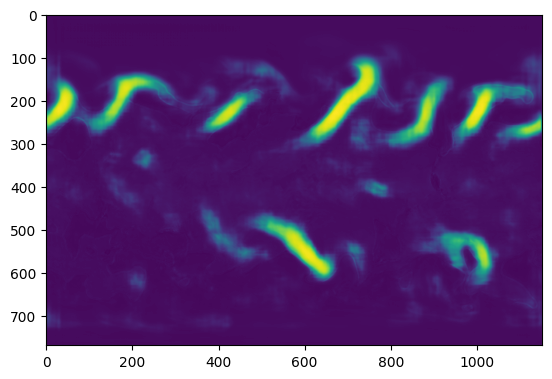

In [17]:
plt.imshow(PRED[1,0,:,:].cpu())

In [33]:
import torch
from torch.utils.data import DataLoader

# ─── helper: collate that keeps y_cons but ignores raw lists ────────────────
def collate_test(batch):
    xs, _, y_cons = zip(*batch)          # y_lists not needed for SegNet
    return torch.stack(xs), torch.stack(y_cons)

# ─── core routine ───────────────────────────────────────────────────────────
def predict_with_gt(ckpt_path : str,
                    data_dir  : str,
                    batch_size: int = 4,
                    device    : str = "cuda"  # or "cpu"
                   ) -> tuple[torch.Tensor, torch.Tensor]:

    ds = ARMultiAnnDataset(data_dir, ["TMQ"])          # TMQ only
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    collate_fn=collate_test, pin_memory=(device=="cuda"))

    # load SegNet
    seg = SegNet().to(device).eval()
    seg.load_state_dict(torch.load(ckpt_path, map_location=device))

    preds, gts = [], []
    autocast = torch.amp.autocast
    with torch.no_grad(), autocast(device_type=device, dtype=torch.float16):
        for x_vars, y_cons in dl:
            x_vars = x_vars.to(device)
            logits = seg(x_vars)                 # (B,1,H,W)
            preds.append(torch.sigmoid(logits))  # fp16
            gts.append(y_cons.to(device))        # fp32

    PRED = torch.cat(preds, 0)                   # [N,1,H,W]
    GT   = torch.cat(gts, 0)                     # [N,1,H,W]
    return PRED, GT


In [38]:
pred, gt = predict_with_gt(
    ckpt_path = "/home/sbk29/data/github_AR/AR_detection/u-net/runs/arseg/segnet_final.pt"  ,
    data_dir  = "/home/sbk29/data/AR/test",
    batch_size= 4,
    device    = "cuda"
)

print("pred", pred.shape, pred.dtype, pred.device)
print("gt  ", gt.shape,   gt.dtype,   gt.device)


/tmp/ipykernel_1232317/1610774988.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  seg.load_state_dict(torch.load(ckpt_path, map_location=device))


pred torch.Size([16, 1, 768, 1152]) torch.float16 cuda:0
gt   torch.Size([16, 1, 768, 1152]) torch.float32 cuda:0


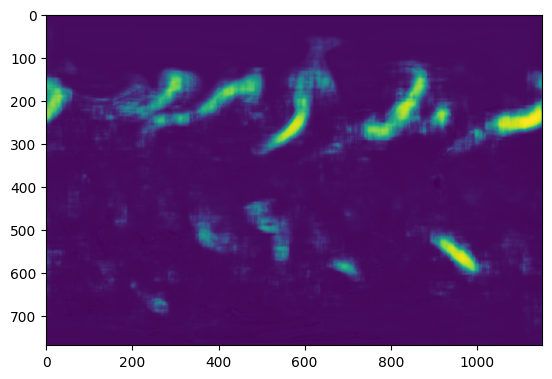

In [41]:
plt.imshow(pred[13,0,:,:].cpu())

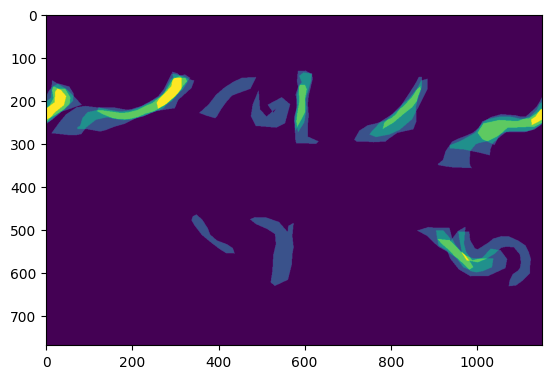

In [42]:
plt.imshow(gt[13,0,:,:].cpu())

In [ ]:
true_mask = np.array(gt[:,0,:,:].cpu()>0.3)  # Size : (B, 768, 1152)
score_whole = np.array(pred.cpu()) # Size : (B, 1, 768, 1152)

In [ ]:
import numpy as np
from scipy.stats import beta, bernoulli
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import glob
import re
import xarray as xr # If used in your ARMultiAnnDataset
import multiprocessing as mp
from scipy import ndimage # For connected components in placeholder shape prior
from typing   import List, Tuple


FNAME_RE = re.compile(r"data-(\d{4}-\d{2}-\d{2})-.*?_(\d+)\.nc$")

class ARMultiAnnDataset(torch.utils.data.Dataset):
    def __init__(self, root: str | Path, var_names: List[str]):
        super().__init__()
        self.root, self.var_names = Path(root), var_names

        by_date = {}
        for f in glob.glob(str(self.root / "*.nc")):
            m = FNAME_RE.search(Path(f).name)
            if m:
                by_date.setdefault(m.group(1), {})[int(m.group(2))] = Path(f)

        self.samples = sorted(by_date.items())
        self.real_max_ann = max(len(d) for _,d in self.samples)

    def _load_nc(self, path: Path) -> Tuple[torch.Tensor, torch.Tensor]:
        ds = xr.open_dataset(path, engine="netcdf4")

        # squeeze() drops ANY singleton dimension, e.g. the leading "time=1"
        vars_arr = [
            torch.as_tensor(ds[v].values).squeeze()     # (H, W) after squeeze
            for v in self.var_names
        ]
        x = torch.stack(vars_arr).float()               # [C, H, W]
        
        raw = torch.as_tensor(ds["LABELS"].values).squeeze()
        y   = (raw == 2).float().unsqueeze(0) 

        # y = torch.as_tensor(ds["LABELS"].values).squeeze().unsqueeze(0).float()
        ds.close()
        return x, y

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        _, ann_map = self.samples[idx]
        x_vars, y_list = None, []
        for p in ann_map.values():
            x, y = self._load_nc(p)
            if x_vars is None: x_vars = x
            y_list.append(y)
        y_cons = torch.stack(y_list).mean(0)
        return x_vars, y_list, y_cons      # variable-length list

def collate_var(batch):
    xs, y_lists, y_cons = zip(*batch)
    return torch.stack(xs), list(y_lists), torch.stack(y_cons)



# --- MCMC Helper functions (BETA_PRIORS, LAMBDA_SMOOTH, update_rater_performance, etc.) ---
# (These are mostly the same, but calculate_log_prob_L_pixel is now LOCAL)
BETA_PRIOR_SE_A, BETA_PRIOR_SE_B = 2, 2
BETA_PRIOR_SP_A, BETA_PRIOR_SP_B = 2, 2
LAMBDA_SMOOTH = 1.0 # Strength for local smoothness prior

# New Hyperparameter for the global shape prior
LAMBDA_SHAPE = 0.5 # Adjust based on the scale of your shape energy/log-prior

def update_rater_performance(L_current, rater_mask_k):
    # (Identical to previous version)
    N_11 = np.sum((L_current == 1) & (rater_mask_k == 1))
    N_10 = np.sum((L_current == 1) & (rater_mask_k == 0))
    N_00 = np.sum((L_current == 0) & (rater_mask_k == 0))
    N_01 = np.sum((L_current == 0) & (rater_mask_k == 1))
    se_k_posterior_a = BETA_PRIOR_SE_A + N_11
    se_k_posterior_b = BETA_PRIOR_SE_B + N_10
    new_se_k = np.clip(beta.rvs(se_k_posterior_a, se_k_posterior_b), 0.01, 0.99)
    sp_k_posterior_a = BETA_PRIOR_SP_A + N_00
    sp_k_posterior_b = BETA_PRIOR_SP_B + N_01
    new_sp_k = np.clip(beta.rvs(sp_k_posterior_a, sp_k_posterior_b), 0.01, 0.99)
    return new_se_k, new_sp_k

def get_neighbors(r, c, img_dims, connectivity=8):
    # (Updated version for 8-connectivity)
    neighbors = []
    if r > 0: neighbors.append((r - 1, c))
    if r < img_dims[0] - 1: neighbors.append((r + 1, c))
    if c > 0: neighbors.append((r, c - 1))
    if c < img_dims[1] - 1: neighbors.append((r, c + 1))
    if connectivity == 8:
        if r > 0 and c > 0: neighbors.append((r - 1, c - 1))
        if r > 0 and c < img_dims[1] - 1: neighbors.append((r - 1, c + 1))
        if r < img_dims[0] - 1 and c > 0: neighbors.append((r + 1, c - 1))
        if r < img_dims[0] - 1 and c < img_dims[1] - 1: neighbors.append((r + 1, c + 1))
    return neighbors

def calculate_log_prob_L_pixel_local(r, c, L_val, L_current, rater_masks_all,
                                     se_raters, sp_raters, img_dims):
    """
    Calculates log-probability for a pixel flip based ONLY on
    local likelihood (rater agreement) and local smoothness prior.
    The global shape prior is NOT included here.
    """
    log_p = 0.0
    eps = 1e-9
    # Likelihood part
    for k in range(len(rater_masks_all)):
        R_kij = rater_masks_all[k][r, c]
        se_k = se_raters[k]
        sp_k = sp_raters[k]
        if L_val == 1:
            if R_kij == 1: log_p += np.log(se_k if se_k > eps else eps)
            else: log_p += np.log((1 - se_k) if (1 - se_k) > eps else eps)
        else: # L_val == 0
            if R_kij == 0: log_p += np.log(sp_k if sp_k > eps else eps)
            else: log_p += np.log((1 - sp_k) if (1 - sp_k) > eps else eps)

    # Local smoothness prior part
    smoothness_penalty = 0
    neighbors = get_neighbors(r, c, img_dims, connectivity=8) # Using 8-connectivity
    for nr, nc in neighbors:
        if L_val != L_current[nr, nc]:
            smoothness_penalty += 1
    log_p += -LAMBDA_SMOOTH * smoothness_penalty
    return log_p

def calculate_global_shape_log_prior(L_mask, lambda_shape_param):
    """
    Placeholder for calculating the log of the global shape prior.
    This is where your SDF analysis or other global metrics would go.
    L_mask: The full 2D binary mask.
    lambda_shape_param: Strength of this prior.

    For demonstration, a VERY simple placeholder:
    - Penalize if there is not exactly one connected component.
    - Penalize if the AR is "too small" or "too large".
    A real implementation would use SDF properties or sophisticated AR metrics.
    """
    if np.sum(L_mask) < 10 : # If mask is essentially empty, no shape penalty/bonus
        return 0.0

    labeled_mask, num_features = ndimage.label(L_mask)
    log_prior_shape = 0.0

    # 1. Penalize if not roughly one main AR feature
    # This is a very crude way to encourage a single, coherent AR.
    # A more advanced method would analyze the properties of the largest component.
    if num_features == 0 :
        log_prior_shape -= 10 # Penalize empty mask if sum was > 0 but no features (should not happen)
    elif num_features > 2: # Penalize if it's too fragmented
        log_prior_shape -= (num_features - 1) * 2.0 # Penalty increases with fragmentation

    # 2. Placeholder: Basic aspect ratio of the largest component
    if num_features > 0:
        largest_component_size = 0
        largest_component_label = 0
        for i in range(1, num_features + 1):
            size = np.sum(labeled_mask == i)
            if size > largest_component_size:
                largest_component_size = size
                largest_component_label = i
        
        if largest_component_label > 0:
            component_mask = (labeled_mask == largest_component_label)
            rows, cols = np.where(component_mask)
            if rows.size > 5: # Minimum size for aspect ratio calculation
                height = rows.max() - rows.min() + 1
                width = cols.max() - cols.min() + 1
                aspect_ratio = max(height, width) / (min(height, width) + eps) # eps to avoid div by zero
                
                # Reward elongation, penalize "square-ish" or non-elongated
                # Ideal AR is long and narrow, so high aspect ratio is good.
                if aspect_ratio < 2.0: # Penalize if not at least 2:1
                    log_prior_shape -= (2.0 - aspect_ratio) * 1.0
                elif aspect_ratio > 1.5: # Slight reward for being somewhat elongated
                    log_prior_shape += (aspect_ratio - 1.5) * 0.5


    # The returned value should be log(P_shape(L_mask))
    # which is often -lambda_shape * Energy_shape(L_mask)
    return lambda_shape_param * log_prior_shape # Note: lambda_shape_param scales the effect.
                                            # If energy is defined as something to minimize,
                                            # then it's -lambda_shape_param * energy


def run_mcmc_for_image(rater_masks_all, img_dims, n_raters,
                       L_initial_guess=None,
                       n_global_steps=100, # Total global MCMC iterations
                       n_gibbs_sweeps_local=5, # Gibbs sweeps for local refinement
                       n_burn_in_global=20,  # Burn-in for the global MCMC
                       image_idx_for_print="N/A"):
    """
    Main MCMC loop for a single image, incorporating global shape prior
    via Metropolis-Hastings after local Gibbs sweeps.
    """
    # Initialize L
    if L_initial_guess is not None and L_initial_guess.shape == img_dims:
        L_current = L_initial_guess.copy().astype(int)
    else:
        L_current = np.random.randint(0, 2, size=img_dims) # Random start if no/bad initial

    # Initialize rater parameters
    se_raters = [beta.rvs(BETA_PRIOR_SE_A, BETA_PRIOR_SE_B) for _ in range(n_raters)]
    sp_raters = [beta.rvs(BETA_PRIOR_SP_A, BETA_PRIOR_SP_B) for _ in range(n_raters)]

    L_samples = []
    se_samples = [[] for _ in range(n_raters)]
    sp_samples = [[] for _ in range(n_raters)]

    # Calculate initial global shape prior for L_current
    log_global_prior_L_current = calculate_global_shape_log_prior(L_current, LAMBDA_SHAPE)

    print_freq_global = n_global_steps // 10 if n_global_steps >=10 else 1

    for g_step in range(n_global_steps):
        if g_step > 0 and g_step % print_freq_global == 0:
             print(f"    (Img {image_idx_for_print}, Proc {mp.current_process().pid if 'mp' in globals() else 'main'}) Global Step {g_step}/{n_global_steps}")

        # 1. Update Rater Performance
        for k_rater in range(n_raters):
            se_raters[k_rater], sp_raters[k_rater] = update_rater_performance(L_current, rater_masks_all[k_rater])

        # 2. Propose L_candidate via Local Gibbs Sweeps
        L_candidate = L_current.copy()
        for _ in range(n_gibbs_sweeps_local): # Local refinement sweeps
            pixel_indices = [(r, c) for r in range(img_dims[0]) for c in range(img_dims[1])]
            np.random.shuffle(pixel_indices)
            for r_pix, c_pix in pixel_indices:
                log_p_L_is_1_local = calculate_log_prob_L_pixel_local(r_pix, c_pix, 1, L_candidate, rater_masks_all, se_raters, sp_raters, img_dims)
                log_p_L_is_0_local = calculate_log_prob_L_pixel_local(r_pix, c_pix, 0, L_candidate, rater_masks_all, se_raters, sp_raters, img_dims)
                
                max_log_p = max(log_p_L_is_1_local, log_p_L_is_0_local)
                if np.isneginf(max_log_p): prob_L_is_1_normalized = 0.5
                else:
                    p_L_is_1 = np.exp(log_p_L_is_1_local - max_log_p)
                    p_L_is_0 = np.exp(log_p_L_is_0_local - max_log_p)
                    sum_p = p_L_is_1 + p_L_is_0
                    if sum_p > 0: prob_L_is_1_normalized = p_L_is_1 / sum_p
                    else: prob_L_is_1_normalized = 0.5
                L_candidate[r_pix, c_pix] = bernoulli.rvs(prob_L_is_1_normalized)
        
        # 3. Metropolis-Hastings step for Global Shape Prior
        # The proposal L_candidate was generated using P_local(L|Data,Theta).
        # We accept it based on the P_global_shape.
        log_global_prior_L_candidate = calculate_global_shape_log_prior(L_candidate, LAMBDA_SHAPE)
        
        # Log Acceptance Ratio: log(P_global(L_cand)) - log(P_global(L_curr))
        # This implicitly assumes the proposal probability related to P_local roughly cancels or
        # that this is a Metropolis adjustment for the part of the prior not included in Gibbs.
        log_acceptance_ratio = log_global_prior_L_candidate - log_global_prior_L_current

        if np.log(np.random.rand()) < log_acceptance_ratio:
            L_current = L_candidate.copy()
            log_global_prior_L_current = log_global_prior_L_candidate # Update current global prior value
            # print(f"        (Img {image_idx_for_print}) Global proposal accepted.") # Can be too verbose

        # 4. Store Samples (after global burn-in)
        if g_step >= n_burn_in_global:
            L_samples.append(L_current.copy())
            for k_rater in range(n_raters):
                se_samples[k_rater].append(se_raters[k_rater])
                sp_samples[k_rater].append(sp_raters[k_rater])
                
    return L_samples, se_samples, sp_samples

# --- Worker Function for Multiprocessing (Calls the new MCMC loop) ---
def process_image_worker(args):
    image_idx, x_vars_tensor, y_list_tensors, y_cons_tensor, \
    n_global_mcmc_steps, n_gibbs_sweeps_local, n_global_burn_in = args
    
    worker_pid = mp.current_process().pid
    # Print progress less frequently
    if image_idx % (mp.cpu_count() * 2 if 'mp' in globals() and mp.cpu_count() > 0 else 4) == 0 :
        print(f"[Worker {worker_pid}] Starting original image index {image_idx}...")

    # Data Preprocessing
    if not y_list_tensors: return image_idx, None, []
    rater_masks_list_np = []
    for r_idx, rater_mask_tensor in enumerate(y_list_tensors):
        if not torch.is_tensor(rater_mask_tensor) or rater_mask_tensor.ndim != 3 or rater_mask_tensor.shape[0] != 1:
            continue
        rater_masks_list_np.append(rater_mask_tensor.squeeze(0).cpu().numpy().astype(int))
    if not rater_masks_list_np: return image_idx, None, []

    current_img_dims = rater_masks_list_np[0].shape
    current_n_raters = len(rater_masks_list_np)

    # L_initial_guess for run_mcmc_for_image will be None to ensure random start
    L_initial_for_mcmc = None # As per user's request for null initial guess

    try:
        L_samples, se_samples_img, sp_samples_img = run_mcmc_for_image(
            rater_masks_list_np, current_img_dims, current_n_raters,
            L_initial_guess=L_initial_for_mcmc,
            n_global_steps=n_global_mcmc_steps,
            n_gibbs_sweeps_local=n_gibbs_sweeps_local,
            n_burn_in_global=n_global_burn_in,
            image_idx_for_print=image_idx
        )

        L_posterior_mean = None
        rater_params_current_img = []
        if L_samples:
            L_posterior_mean = np.mean(L_samples, axis=0)
            estimated_se_img = [np.mean(s) for s in se_samples_img]
            estimated_sp_img = [np.mean(s) for s in sp_samples_img]
            rater_params_current_img = [{'Se': se_k, 'Sp': sp_k} for se_k, sp_k in zip(estimated_se_img, estimated_sp_img)]
        return image_idx, L_posterior_mean, rater_params_current_img
    except Exception as e_worker:
        print(f"[Worker {worker_pid}, Img Idx {image_idx}] ERROR during MCMC: {e_worker}")
        import traceback
        traceback.print_exc()
        return image_idx, None, []


# --- Main Execution with Multiprocessing ---
if __name__ == '__main__':
    try:
        mp.set_start_method('spawn', force=True)
    except RuntimeError:
        print("Note: Multiprocessing start method already set or could not be set to 'spawn'.")

    # --- USER: Instantiate Your PyTorch Dataset ---
    # ... (Your dataset instantiation logic - same as before) ...
    my_ar_dataset_instance = None # Placeholder
    try:
        # Replace with your actual dataset path and var_names
        # from pathlib import Path # Ensure Path is imported if used in ARMultiAnnDataset
        ROOT_PATH_ACTUAL = "/home/sbk29/data/AR/test"
        VAR_NAMES_ACTUAL = ["TMQ"]
        my_ar_dataset_instance = ARMultiAnnDataset(root=ROOT_PATH_ACTUAL, var_names=VAR_NAMES_ACTUAL)
        if len(my_ar_dataset_instance) == 0:
            print("User dataset initialized but found 0 samples. Check dataset path and logic.")
            my_ar_dataset_instance = None
        pass # This line should be replaced by your dataset instantiation
    except Exception as e:
        print(f"Could not instantiate user's ARMultiAnnDataset: {e}. ")
        my_ar_dataset_instance = None

    
    # (Using placeholder data for brevity, replace with your actual dataset instantiation)
    if my_ar_dataset_instance is None:
        print("Using placeholder data...")
        num_dataset_images = 10; IMG_DIMS_DATASET = (20, 30); N_RATERS_DATASET_MIN, N_RATERS_DATASET_MAX = 2, 4
        placeholder_dataset_main = []
        for i in range(num_dataset_images):
            x_vars_ph = torch.randn(2, IMG_DIMS_DATASET[0], IMG_DIMS_DATASET[1])
            num_r = np.random.randint(N_RATERS_DATASET_MIN, N_RATERS_DATASET_MAX + 1)
            y_list_ph = [(torch.rand(1, IMG_DIMS_DATASET[0], IMG_DIMS_DATASET[1]) > 0.7).float() for _ in range(num_r)]
            y_cons_ph = torch.stack(y_list_ph).mean(0) if y_list_ph else torch.zeros(1, IMG_DIMS_DATASET[0], IMG_DIMS_DATASET[1])
            placeholder_dataset_main.append((x_vars_ph, y_list_ph, y_cons_ph))
        data_source_main = placeholder_dataset_main; data_source_len_main = len(placeholder_dataset_main)
        data_source_getitem_main = lambda idx_ph: placeholder_dataset_main[idx_ph]
    else:
        data_source_main = my_ar_dataset_instance; data_source_len_main = len(my_ar_dataset_instance)
        data_source_getitem_main = lambda idx_ds: my_ar_dataset_instance[idx_ds]
    # --- End Dataset Handling ---

    # New MCMC Hyperparameters
    N_GLOBAL_MCMC_STEPS = 100  # Total global Metropolis-Hastings steps
    N_GIBBS_SWEEPS_LOCAL = 5   # Number of local Gibbs sweeps to generate a candidate L
    N_GLOBAL_BURN_IN = 10      # Burn-in period for the global MCMC chain

    NUM_CORES = min(40, mp.cpu_count() - 1 if mp.cpu_count() > 1 else 1) # Reduce for testing this complex change
    print(f"Number of CPU cores to be used by Pool: {NUM_CORES}")

    tasks_args_list = []
    for i in range(data_source_len_main):
        try:
            x_vars_tensor, y_list_tensors, y_cons_tensor = data_source_getitem_main(i)
            # Pass new MCMC parameters to the worker
            tasks_args_list.append((i, x_vars_tensor, y_list_tensors, y_cons_tensor,
                                    N_GLOBAL_MCMC_STEPS, N_GIBBS_SWEEPS_LOCAL, N_GLOBAL_BURN_IN))
        except Exception as e_fetch:
            print(f"Error fetching data for image index {i}: {e_fetch}. Skipping this image.")

    print(f"\nStarting parallel processing of {len(tasks_args_list)} images using {NUM_CORES} cores...")
    print(f"MCMC settings: Global Steps={N_GLOBAL_MCMC_STEPS}, Local Gibbs Sweeps={N_GIBBS_SWEEPS_LOCAL}, Global Burn-in={N_GLOBAL_BURN_IN}")
    print(f"LAMBDA_SMOOTH={LAMBDA_SMOOTH}, LAMBDA_SHAPE={LAMBDA_SHAPE}")


    results_from_pool = []
    with mp.Pool(processes=NUM_CORES) as pool:
        results_from_pool = pool.map(process_image_worker, tasks_args_list)

    # --- Process and Store Results (same as before) ---
    all_estimated_L_masks_posterior_mean = [None] * data_source_len_main
    all_estimated_rater_params_per_image = [None] * data_source_len_main
    successful_processes = 0
    for result_item in results_from_pool:
        if result_item is not None:
            original_idx, L_mean, rater_params = result_item
            if L_mean is not None:
                all_estimated_L_masks_posterior_mean[original_idx] = L_mean
                all_estimated_rater_params_per_image[original_idx] = rater_params
                successful_processes +=1
    print(f"\n--- Overall Parallel Processing Complete ---")
    print(f"Successfully processed results for {successful_processes}/{len(tasks_args_list)} images.")

    # --- Visualization (same as before, ensure you use data_source_getitem_main for original data) ---
    # ... (your visualization code) ...
    # (Example for the first successfully processed image)
    first_successful_plot_idx = -1
    for idx_plot, l_mask_plot in enumerate(all_estimated_L_masks_posterior_mean):
        if l_mask_plot is not None:
            first_successful_plot_idx = idx_plot
            break
    if first_successful_plot_idx != -1:
        print(f"\nVisualizing results for original Image Index {first_successful_plot_idx}")
        _, y_list_tensors_plot, y_cons_tensor_plot = data_source_getitem_main(first_successful_plot_idx) # Get original data
        rater_masks_plot_np_viz = [m.squeeze(0).cpu().numpy() for m in y_list_tensors_plot]
        num_plot_cols_viz = len(rater_masks_plot_np_viz) + 2
        fig, axes_viz = plt.subplots(1, num_plot_cols_viz, figsize=(min(20, 4 * num_plot_cols_viz), 4)) # Cap width
        if num_plot_cols_viz == 1: axes_viz = np.array([axes_viz])
        for k_plot_viz in range(len(rater_masks_plot_np_viz)):
            axes_viz[k_plot_viz].imshow(rater_masks_plot_np_viz[k_plot_viz], cmap='gray', interpolation='nearest')
            axes_viz[k_plot_viz].set_title(f"Img Idx {first_successful_plot_idx} - Rater {k_plot_viz+1}")
            axes_viz[k_plot_viz].axis('off')
        axes_viz[len(rater_masks_plot_np_viz)].imshow(y_cons_tensor_plot.squeeze(0).cpu().numpy(), cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
        axes_viz[len(rater_masks_plot__np_viz)].set_title(f"Img Idx {first_successful_plot_idx} - Original Consensus")
        axes_viz[len(rater_masks_plot_np_viz)].axis('off')
        axes_viz[len(rater_masks_plot_np_viz)+1].imshow(all_estimated_L_masks_posterior_mean[first_successful_plot_idx], cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
        axes_viz[len(rater_masks_plot_np_viz)+1].set_title(f"Img Idx {first_successful_plot_idx} - Posterior Mean L")
        axes_viz[len(rater_masks_plot_np_viz)+1].axis('off')
        plt.tight_layout()
        plt.show()


Number of CPU cores to be used by Pool: 40

Starting parallel processing of 16 images using 40 cores...
MCMC settings: Global Steps=100, Local Gibbs Sweeps=5, Global Burn-in=10
LAMBDA_SMOOTH=1.0, LAMBDA_SHAPE=0.5


Process SpawnPoolWorker-21:
Traceback (most recent call last):
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_image_worker' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
Process SpawnPoolWorker-23:
Traceback (most recent call last):
  File "/home/sbk29/.conda/envs/turbulence/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/sbk29/.conda/

KeyboardInterrupt: 

44